### Overview

Perform PCA Analyasis on just the 2's and 6's from MNIST

In [2]:
import torch
from torchvision import datasets, transforms
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn

Download MNIST dataset

In [3]:
mnist = datasets.MNIST(root='data', download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 4.12MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.50MB/s]


In [5]:
X = mnist.data.numpy()
y = mnist.targets.numpy()

print(X.shape)
print(y.shape)


(60000, 28, 28)
(60000,)


Samples (2s and 6s): 11876
Original dimension: 784
Components for 90% variance: 84
Components for 95% variance: 147
Components for 99% variance: 312


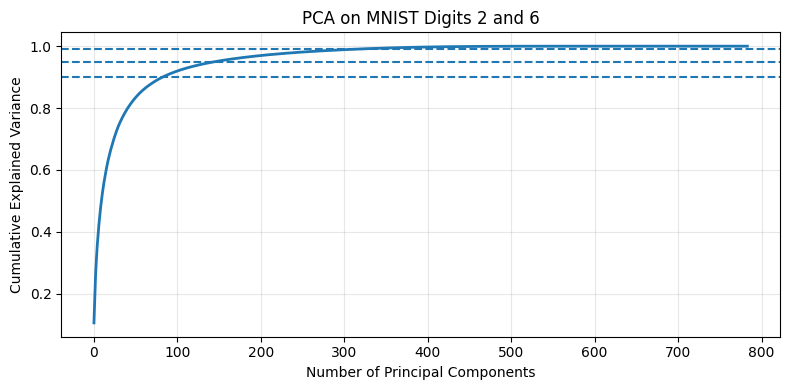

In [6]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Keep only digits 2 and 6
mask_26 = (y == 2) | (y == 6)
X_26 = X[mask_26]
y_26 = y[mask_26]

# Flatten images for PCA: (n_samples, 28, 28) -> (n_samples, 784)
X_26_flat = X_26.reshape(X_26.shape[0], -1).astype(np.float32)

# Standard PCA on centered data
pca = PCA()
pca.fit(X_26_flat)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Dimensionality estimates by retained variance
k90 = np.searchsorted(cumulative, 0.90) + 1
k95 = np.searchsorted(cumulative, 0.95) + 1
k99 = np.searchsorted(cumulative, 0.99) + 1

print(f"Samples (2s and 6s): {X_26_flat.shape[0]}")
print(f"Original dimension: {X_26_flat.shape[1]}")
print(f"Components for 90% variance: {k90}")
print(f"Components for 95% variance: {k95}")
print(f"Components for 99% variance: {k99}")

# Visualize cumulative explained variance
plt.figure(figsize=(8, 4))
plt.plot(cumulative, linewidth=2)
plt.axhline(0.90, linestyle='--')
plt.axhline(0.95, linestyle='--')
plt.axhline(0.99, linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA on MNIST Digits 2 and 6')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()